In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
!nvidia-smi
import numpy as np
from collections import namedtuple, deque
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import gym
import math
import random
import matplotlib
import matplotlib.pyplot as plt

Sun Nov  5 04:43:51 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 520.61.05    Driver Version: 520.61.05    CUDA Version: 11.8     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA GeForce ...  On   | 00000000:05:00.0 Off |                  N/A |
|  0%   31C    P8    13W / 198W |      1MiB /  8192MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  NVIDIA GeForce ...  On   | 00000000:06:00.0 Off |                  N/A |
| 27%   

In [2]:
env = gym.make("CartPole-v0")

/nfs/home/dem1110/.conda/envs/mldsrl/lib/python3.8/site-packages/gym/envs/registration.py:555: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(


In [3]:
class buildDQN(nn.Module):
    def __init__(self, state_size, actions_num):
        super(buildDQN, self).__init__()
        self.layer1 = nn.Linear(state_size, 128)
        nn.init.kaiming_normal_(self.layer1.weight, nonlinearity='relu') 
        self.layer2 = nn.Linear(128, 128)
        nn.init.kaiming_normal_(self.layer2.weight, nonlinearity='relu') 
        self.layer3 = nn.Linear(128, actions_num)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = self.layer3(x)
        return x

In [4]:
actions_num = env.action_space.n
state, info = env.reset()
state_size = len(state)

policy_net = buildDQN(state_size, actions_num)
target_net = buildDQN(state_size, actions_num)
target_net.load_state_dict(policy_net.state_dict())

<All keys matched successfully>

In [5]:
###Load model

policy_net = torch.load('policy_net_cartpole_v4.pth')


In [6]:

num_episodes = 500
Sample_Episodes = []
for episode in range(num_episodes):
    state, info = env.reset()
    state = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
    total_reward = 0
    done = False
    terminated=False
    truncated =False
    while (not terminated) and (not truncated):
        action = policy_net(state).max(1)[1].view(1, 1)
        observation, reward, terminated, truncated, info = env.step(action.item())
        reward = torch.tensor([reward])
        done = terminated or truncated
        # Move to the next state
        state = torch.tensor(observation, dtype=torch.float32).unsqueeze(0)

        total_reward+=reward
    
    Sample_Episodes.append(float(total_reward))
    print(f"Episode: {episode}, Reward: {float(total_reward)}")
np_eps_rewards_Sample = np.array(Sample_Episodes)
np.save('sample500_np_eps_rewards_cartpole.npy', np_eps_rewards_Sample)

/nfs/home/dem1110/.conda/envs/mldsrl/lib/python3.8/site-packages/gym/utils/passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


Episode: 0, Reward: 200.0
Episode: 1, Reward: 200.0
Episode: 2, Reward: 200.0
Episode: 3, Reward: 200.0
Episode: 4, Reward: 200.0
Episode: 5, Reward: 200.0
Episode: 6, Reward: 200.0
Episode: 7, Reward: 200.0
Episode: 8, Reward: 200.0
Episode: 9, Reward: 200.0
Episode: 10, Reward: 200.0
Episode: 11, Reward: 200.0
Episode: 12, Reward: 200.0
Episode: 13, Reward: 200.0
Episode: 14, Reward: 200.0
Episode: 15, Reward: 200.0
Episode: 16, Reward: 200.0
Episode: 17, Reward: 200.0
Episode: 18, Reward: 200.0
Episode: 19, Reward: 200.0
Episode: 20, Reward: 200.0
Episode: 21, Reward: 200.0
Episode: 22, Reward: 200.0
Episode: 23, Reward: 200.0
Episode: 24, Reward: 200.0
Episode: 25, Reward: 200.0
Episode: 26, Reward: 200.0
Episode: 27, Reward: 200.0
Episode: 28, Reward: 200.0
Episode: 29, Reward: 200.0
Episode: 30, Reward: 200.0
Episode: 31, Reward: 200.0
Episode: 32, Reward: 200.0
Episode: 33, Reward: 200.0
Episode: 34, Reward: 200.0
Episode: 35, Reward: 200.0
Episode: 36, Reward: 200.0
Episode: 37

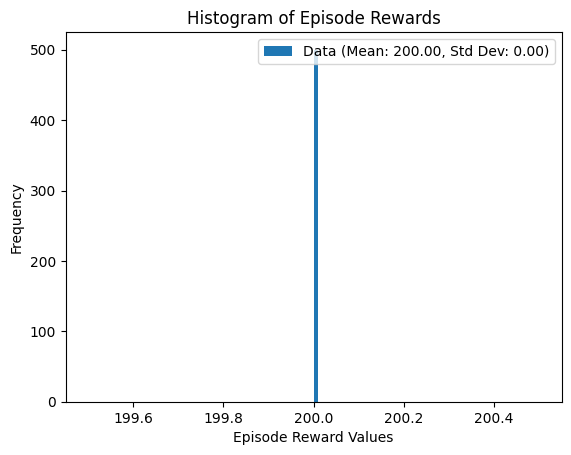

<Figure size 640x480 with 0 Axes>

In [7]:
#numpy_array = np.array([tensor.numpy() for tensor in Sample_Episodes])
numpy_array = np.array(Sample_Episodes)
mean = np.mean(numpy_array)
std_dev = np.std(numpy_array)

legend_label = f'Data (Mean: {mean:.2f}, Std Dev: {std_dev:.2f})'

plt.hist(Sample_Episodes, bins=100)
plt.xlabel('Episode Reward Values')
plt.ylabel('Frequency')
plt.legend([legend_label])
plt.title('Histogram of Episode Rewards')
plt.show()
plt.savefig('Histogramof500episodes_cartpole.png')